# Two-Port S-Parameter Sweep

Measures S11, S12, S21 and S22 of the MM4250 at a list of switch positions and saves each position as a QCoDeS run in `mm4250_sweeps.db`. All four S-parameters come from a **single sweep** per position -- the P5004B handles the reverse sweep for S12/S22 itself.

**Files it needs**, all in the same folder as this notebook: `vna_measure.py` (the measurement), `sweep_db.py` (saving), `read_db.py` (reading back) and `plots.py` (plots). The drivers are found by walking up to the repo or framework folder that holds `drivers/`.

**What it writes**, beside this notebook:

```
mm4250_sweeps.db                                                              every sweep, always
Sweeps/<serials>/<date>/<temp>/<setup>_<cal|uncal>/<position>_run<id>.s2p   only with touchstone=True
figures/<serials>/<date>/<temp>/<name>.png                                    only when a plot is saved
```

The database is the record -- every number a `.s2p` would hold, at full precision, plus what the VNA was doing. Each sweep returns its **run ids**, which is what `plot_sweep`, `load_run` and `export_touchstone` take. Whether a sweep was calibrated is read off the VNA, not typed: runs are grouped as `<setup>_cal` or `<setup>_uncal`, and a sweep stops if the correction changes partway through.

**Order:** run top to bottom -- imports, connect, sweep setup, cal kit, then a single measurement to check things look right before a batch. Finish with **Close**.

**Instruments:** this notebook connects its own `ksvna`/`switch`. To sweep from `QCodesMeasurmentFramework.ipynb`'s kernel instead, skip the connect cell and call `run_twoport_sweep(...)` there -- it finds instruments registered under those names. Never both in one kernel: the switch's USB connection is exclusive.

## Imports

Finds this notebook's folder and puts it on the path (that's where `vna_measure`, `sweep_db`, `read_db` and `plots` live), then walks up until it finds a `drivers/` folder -- this repo on a laptop, the framework repo on the DAQ -- and imports the VNA and switch drivers from there. Both paths are printed so you can check it found the right ones.

Also imports everything the later cells use: `setup_sweep`/`measure_2port` for measuring, `run_twoport_sweep` for saving, `plot_measurement`/`plot_sweep`/`summarize` for looking, and `list_runs`/`load_run`/`export_touchstone` for reading the database back.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

# The drivers live in whichever repo root is above this notebook -- this
# folder if it's the mm4250-switch repo, or the framework repo if these
# files were copied into users/<name>/. Walk up until we find it.
try:
    here = Path(_dh[0])  # Jupyter sets _dh[0] to this notebook's directory
except NameError:
    here = Path.cwd()
if str(here) not in sys.path:
    sys.path.insert(0, str(here))       # vna_measure / sweep_db live here

root = here
while not (root / "drivers").is_dir() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))       # drivers/ live here
print(f"notebook folder: {here}")
print(f"drivers from:    {root}")

from drivers.KeysightVNA_driver import KeysightP5004B
from drivers.MM4250_QCodes_driver import MM4250
from vna_measure import setup_sweep, sweep_settings, measure_2port
from sweep_db import run_twoport_sweep
from plots import plot_measurement, plot_sweep, summarize
from read_db import list_runs, load_run, export_touchstone

notebook folder: /Users/charlieferrari/Documents/Senior Design Project/SD Code/mm4250-switch/measurements
drivers from:    /Users/charlieferrari/Documents/Senior Design Project/SD Code/mm4250-switch


## Connect the VNA and switch

Creates `ksvna` (the Keysight P5004B, over the network) and `switch` (the MM4250, over USB).

Connecting the switch **forces `ALL_OPEN`**, so if you re-run this cell mid-session, re-set your channel afterwards. If the switch fails to connect, another kernel probably still holds it -- close that one first. If `import hid` fails, see the hidapi section of `LAB_SETUP.md`.

In [5]:
ksvna = KeysightP5004B("ksvna", "TCPIP0::QTSF-Measurement::hislip_PXI0_CHASSIS1_SLOT1_INDEX0::INSTR")
switch = MM4250("switch")

Connected to: Keysight Technologies P5004B (serial:MY61400324, firmware:A.19.30.21) in 0.56s
Connected to MM4250 driver board (VID=0x04d8, PID=0xedfb).


## Sweep setup

Sets the VNA's frequency range, number of points, IF bandwidth and source power. Only the settings you pass are changed, so `setup_sweep(points=2001)` nudges one thing and leaves the rest alone. It also always sets the trigger source to `IMM` and turns the RF output on -- without those, a sweep either waits forever or quietly records the noise floor.

Power is capped at 0 dBm (a typo guard: `-20` and `20` are one character apart). For more dynamic range, lower `if_bandwidth` before raising power.

Changing the frequency range, point count or IF bandwidth **invalidates the VNA's calibration** -- the cal set below is only valid for 1 MHz-10 GHz, 10000 points, 1 kHz.

In [15]:
setup_sweep(start=1e6, stop=10e9, points=10000, if_bandwidth=1e3, power=-20, vna=ksvna)

VNA sweep settings:
  0.001 - 10 GHz, 10000 points (LIN)
  IF bandwidth 1000 Hz, power -20 dBm
  averaging OFF
  trigger source IMM


{'start': 1000000.0,
 'stop': 10000000000.0,
 'points': 10000,
 'if_bandwidth': 1000.0,
 'power': -20.0,
 'averages_enabled': False,
 'averages': 1,
 'sweep_type': 'LIN',
 'trigger_source': 'IMM'}

## Set the cal kit

Turns on a saved VNA calibration: `ksvna.write('SENS:CORR:CSET:ACT "<cal set name>",0')`. The trailing `0` keeps the sweep settings from the cell above; `1` would reset them to the cal set's own.

The `VNA_STATE_QUERIES` line makes every run's metadata record which cal set was active, as `vna_cal_set`. To sweep uncalibrated instead, skip this cell or run `ksvna.write('SENS:CORR:CSET:DEAC')` -- either way the sweep files itself as `cal` or `uncal` from what the VNA reports.

In [ ]:
import vna_measure
vna_measure.VNA_STATE_QUERIES["cal_set"] = "SENS:CORR:CSET:ACT? NAME"

ksvna.write('SENS:CORR:CSET:ACT "20260911_1MHz_10GHz_female",0')

## A single measurement

Measures one position and **saves nothing** -- a quick look before committing to a batch. `measure_2port(3)` sets the switch to RF3 and returns `freq` (Hz) and `data`, a dict of complex arrays keyed `"S11"`, `"S12"`, `"S21"`, `"S22"`.

`summarize` prints min, max and a few marker values; `plot_measurement` plots all four in dB. Options, all optional:

```python
plot_measurement(freq, data, title="RF3", phase=True,          # phase panel for electrical length / cable problems
                 xlim=(0, 6), ylim=(-40, 0),                   # GHz, dB
                 colors={"S21": "black"}, save="rf3_check.png")  # save -> figures/
```

Switch set to RF6 (source off during the move)
Measured S11, S12, S21, S22: 1001 points, 0.001 - 10 GHz
RF3
1001 points, 0.001 - 10 GHz
          min dB    max dB    0.001 GHz        5 GHz       10 GHz
S11       -45.30     -9.77       -34.39       -27.37       -15.17
S12       -12.45     -0.25        -0.25        -4.82        -8.05
S21       -12.51     -0.24        -0.24        -4.90        -8.09
S22       -52.60     -9.90       -32.14       -22.29       -13.28


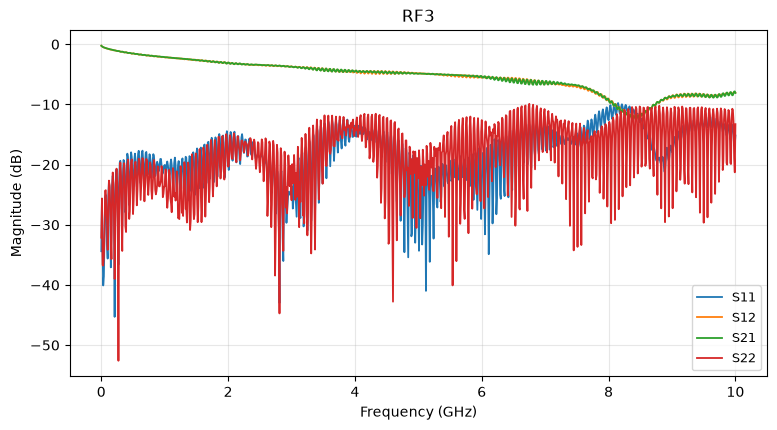

In [ ]:
freq, data = measure_2port(3, vna=ksvna, switch=switch)

summarize(freq, data, title="RF3")
ax = plot_measurement(freq, data, title="RF3") 

# plot_measurement(freq, data, phase=True) adds an unwrapped-phase panel,
# which is what to look at when checking electrical length or chasing a
# cable problem.


## Batch sweep

Measures every entry in `positions` and saves each as a run. Edit the variables at the top each time:

- `positions` -- RF channel numbers, switch state names, or a mix. `[3, "ALL_OPEN"]` measures RF3, then the same cabling with everything open -- that's how you get isolation without touching a cable. States: `"ALL_OPEN"`, `"RFC_RF1"`..`"RFC_RF6"`, `"INTERNAL_LOAD"`, `"INTERNAL_SHORT"`.
- `date_str`, `temp_str`, `switch_serials` -- where the runs are filed.
- `setup` -- the cabling, e.g. `"RF3"` for VNA port 2 on RF3. Combined with the VNA's cal state it names the group: `RF3_cal` / `RF3_uncal` (just `cal` / `uncal` with no setup).

Returns `runs`, the run ids. Add `touchstone=True` to also write `.s2p` files, or write them later with `export_touchstone(runs)`. Add `prompt_between=True` if something has to be re-cabled between positions.

In [8]:
# Edit these for each run, then save the whole set:
positions = [6]        # channels 1-6, state-name strings, or both
date_str = "20260924"        # e.g. "20260920"
temp_str = "295K"            # e.g. "295K", "3K", "25mK"
switch_serials = "SN0078"    # the switch(es) under test, e.g. "0077_0078"
setup = None                 # the cabling, e.g. "RF3" -> folder RF3_cal / RF3_uncal

runs = run_twoport_sweep(positions, date_str, temp_str, switch_serials, setup=setup,
                         vna=ksvna, switch=switch)   # touchstone=True to also write .s2p files
print(f"Sweep complete: runs {runs}")

Recording to C:\Users\QTSF_DAQ\Measuring_scripts\QCoDeS-Measurement-Framework\Users\Charlie_Ferrari\mm4250_sweeps.db
  experiment '20260924_295K_SN0078' (sample 'SN0078')
Measuring RF6...
Switch set to RF6 (source off during the move)
Measured S11, S12, S21, S22: 10000 points, 0.001 - 10 GHz
Starting experimental run with id: 6. 
  recorded run #6 in mm4250_sweeps.db
  saved C:\Users\QTSF_DAQ\Measuring_scripts\QCoDeS-Measurement-Framework\Users\Charlie_Ferrari\Sweeps\20260924_295K\SN0078\raw\RF6_run6.s2p
Sweep complete, .s2p files saved under C:\Users\QTSF_DAQ\Measuring_scripts\QCoDeS-Measurement-Framework\Users\Charlie_Ferrari\Sweeps\20260924_295K\SN0078


## Check the VNA's calibration state

Prints every cal set saved on the VNA, the current sweep settings, whether correction is on (`1`) or off (`0`), and which cal set is active. Worth running before a calibrated sweep to make sure the right cal is on and the sweep settings still match it.

In [ ]:
print("All cal sets: ", ksvna.ask("SENS:CORR:CSET:CAT? NAME").strip())
sweep_settings(vna=ksvna)
print(ksvna.ask("SENS:CORR:STAT?"))
print(ksvna.ask("SENS:CORR:CSET:ACT? NAME"))
#vna_measure.instrument_state(("S11",), vna=ksvna).get("vna_cal_set")

All cal sets:  "20250930_3_11_GHz_female,20251003_5MHz_20GHz_female,20251003_5MHz_20GHz_male,20260408_510MHz_610MHz,20260909_1MHz_10GHz_female,20260911_1MHz_10GHz_female,CH1_CALREG,CH2_CALREG,CH4_CALREG,fridge_2Ghz_4GHz_umux_input_female"
VNA sweep settings:
  0.001 - 10 GHz, 10000 points (LIN)
  IF bandwidth 1000 Hz, power -20 dBm
  averaging OFF
  trigger source IMM
1
"20260911_1MHz_10GHz_female"


'20260911_1MHz_10GHz_female'

## Cal / uncal sweep of one channel

Measures one cabling twice -- VNA port 1 on RFC, port 2 on RF`n` -- first with the cal set on, then with correction off, so the two can be compared directly. Each pass measures RF`n`, `ALL_OPEN`, `INTERNAL_LOAD` and `INTERNAL_SHORT`.

Both calls are identical; the VNA's state decides whether the runs go to `RF<n>_cal` or `RF<n>_uncal`. Change `n`, re-cable, and run again for the next channel. Leaves `runs_cal`, `runs_uncal`, and `runs` (both together) for the plotting cell.

In [26]:
date_str = "20260925"        # e.g. "20260920"
temp_str = "295K"            # e.g. "295K", "3K", "25mK"
switch_serials = "SN0077"    # the switch(es) under test, e.g. "0077_0078"

n=6

ksvna.write('SENS:CORR:CSET:ACT "20260911_1MHz_10GHz_female",0')

# correction ON -> experiment ..._RF<n>_cal
runs_cal = run_twoport_sweep([n, "ALL_OPEN", "INTERNAL_LOAD", "INTERNAL_SHORT"], date_str, temp_str, switch_serials,
                  setup=f"RF{n}", vna=ksvna, switch=switch)

ksvna.write('SENS:CORR:CSET:DEAC')

# correction OFF -> experiment ..._RF<n>_uncal
runs_uncal = run_twoport_sweep([n, "ALL_OPEN", "INTERNAL_LOAD", "INTERNAL_SHORT"], date_str, temp_str, switch_serials,
                  setup=f"RF{n}", vna=ksvna, switch=switch)

runs = runs_cal + runs_uncal
print(f"cal runs {runs_cal}, uncal runs {runs_uncal}")


Recording to C:\Users\QTSF_DAQ\Measuring_scripts\QCoDeS-Measurement-Framework\Users\Charlie_Ferrari\mm4250_sweeps.db
  experiment '20260925_295K_SN0077_CabledRF6_cal' (sample 'SN0077')
Measuring RF6...
Switch set to RF6 (source off during the move)
Measured S11, S12, S21, S22: 10000 points, 0.001 - 10 GHz
Starting experimental run with id: 55. 
  recorded run #55 in mm4250_sweeps.db
  saved Sweeps\calibrations\SN0077\CabledRF6_cal\20260925_295K\SN0077\raw\RF6_run55.s2p
Measuring ALL_OPEN...
Switch set to ALL_OPEN (source off during the move)
Measured S11, S12, S21, S22: 10000 points, 0.001 - 10 GHz
Starting experimental run with id: 56. 
  recorded run #56 in mm4250_sweeps.db
  saved Sweeps\calibrations\SN0077\CabledRF6_cal\20260925_295K\SN0077\raw\ALL_OPEN_run56.s2p
Measuring INTERNAL_LOAD...
Switch set to INTERNAL_LOAD (source off during the move)
Measured S11, S12, S21, S22: 10000 points, 0.001 - 10 GHz
Starting experimental run with id: 57. 
  recorded run #57 in mm4250_sweeps.db
 

WindowsPath('Sweeps/calibrations/SN0077/CabledRF6_uncal/20260925_295K/SN0077')

## Look at the whole sweep

`plot_sweep` overlays every run on one axes, read back from the database. S21 by default: connected channels sit near the top, an isolated state drops to the floor, and the gap is the isolation. `sparam="S11"` for return loss.

What it takes: `runs` from a sweep cell, any list of run ids from any session (`list_runs()` shows what's there), or a folder of `.s2p` files. Cal and uncal runs plotted together are labelled by group.

```python
plot_sweep(runs,
           sparam="S21",
           xlim=(0, 6), ylim=(-100, 5),                 # GHz, dB
           colors=["black", "tab:red"],                 # in run order, or {31: "black"}
           labels=["thru", "open"],                     # legend text, same forms
           title="SN0077 RF1, 295 K",
           save=True)                                   # -> figures/<serials>/<date>/<temp>/
```

`save=True` names the file for you (e.g. `S21_RF1_cal+RF1_uncal_runs31-36.png`); `save="name.pdf"` picks the name and format; a path with folders is used as given. One run on its own, all four S-parameters: `plot_measurement(run=39, save=True)`. Side by side: make `fig, (a, b) = plt.subplots(1, 2)`, pass `ax=a` / `ax=b`, and `save=` on either saves the whole figure.

In [10]:
#ax = plot_sweep(runs)
#ax = plot_sweep([31,39], sparam="S11")
#ax = plot_sweep("Sweeps/SN0077/20260925/295K/RF1_cal", sparam="S11")


## Close

Turns the VNA's RF output off, opens every switch channel, and releases both instruments. Run it before starting another notebook that needs the switch -- the MM4250's USB connection is exclusive.

In [ ]:
ksvna.output(False)
switch.open_all()
ksvna.close()
switch.close()

## Debugging: hidapi

Only needed if `import hid` fails in the connect cell. The first cell tries `pip install hidapi` and imports `hid`; the second checks whether Python can find the `hid` module at all (`None` means it can't, whatever pip says). See the hidapi section of `LAB_SETUP.md` for the fix that works on the DAQ.

In [ ]:
#checking hidapi properly active
import sys, subprocess, importlib
r = subprocess.run([sys.executable, "-m", "pip", "install", "hidapi"], capture_output=True, text=True)
print(r.stdout[-1500:])
print(r.stderr[-1500:])

importlib.invalidate_caches()
try:
    import hid
    print("OK:", hid.__file__)
except Exception as e:
    print("FAILED:". type(e).__name__, e)
print("python:", sys.executable)


0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.



AttributeError: 'str' object has no attribute 'type'

In [ ]:
#more hid stuff
import importlib, importlib.util
importlib.invalidate_caches()
print(importlib.util.find_spec("hid"))

ModuleSpec(name='hid', loader=<_frozen_importlib_external.ExtensionFileLoader object at 0x000002B47ADE9FD0>, origin='c:\\Users\\QTSF_DAQ\\anaconda3\\envs\\QTSF_QCoDeS_env\\Lib\\site-packages\\hid.cp314-win_amd64.pyd')
